# 03 · Metric and baselines

Implements the competition metric (`src/rsna/metrics.py`, tested in `tests/test_metrics.py`) and scores simple baselines that do not look at the images. They set the bar every later model has to clear.

Needs `patients.csv` and `boxes.csv` from `scripts/prepare_data.py`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from rsna.metrics import BOX_COLS, THRESHOLDS, image_score, score_images
from rsna.paths import load_paths

pd.set_option("display.width", 200)

processed = load_paths()["processed_data_dir"]
patients = pd.read_csv(processed / "patients.csv")
boxes = pd.read_csv(processed / "boxes.csv").merge(patients[["patient_id", "fold"]], on="patient_id")
print("patients:", len(patients), "| boxes:", len(boxes))

patients: 26684 | boxes: 9555


## 1. The competition metric

**Question:** How exactly is a submission scored? Every later model is judged with this number, so we write it ourselves in `src/rsna/metrics.py` and check it on cases where we know the answer.

The metric is called "mAP", but it is not the usual average precision:

- For one image and one IoU threshold t, the predicted boxes are taken in order of confidence. Each one is matched to the unmatched true box with the highest IoU, if that IoU is above t. Matched predictions are TP, unmatched predictions FP, unmatched true boxes FN.
- The score at t is TP / (TP + FP + FN). The image score is the mean over the 8 thresholds 0.40, 0.45, ..., 0.75.
- The final score is the mean over images, with two special rules:
  - an image with **no true boxes and at least one prediction scores 0**;
  - an image with **no true boxes and no prediction is skipped**, it does not enter the mean.

Small hand-made cases (boxes are `x, y, width, height`):

In [2]:
BOX = [100, 100, 100, 100]
SHIFTED = [120, 100, 100, 100]  # IoU with BOX = 80 / 120 = 0.667
FAR = [600, 600, 100, 100]      # no overlap with BOX

cases = {
    "exact match":                    ([BOX], [BOX]),
    "shifted box (IoU 0.667)":        ([BOX], [SHIFTED]),
    "extra prediction":               ([BOX], [BOX, FAR]),
    "duplicate prediction":           ([BOX], [BOX, BOX]),
    "one of two boxes missed":        ([BOX, FAR], [BOX]),
    "positive image, no prediction":  ([BOX], []),
    "negative image, one prediction": ([], [BOX]),
    "negative image, no prediction":  ([], []),
}
pd.DataFrame(
    [{"case": name, "true boxes": len(t), "predicted boxes": len(p), "score": image_score(t, p)} for name, (t, p) in cases.items()]
).set_index("case")

,true boxes,predicted boxes,score
case,,,
exact match,1,1,1.00
shifted box (IoU 0.667),1,1,0.75
extra prediction,1,2,0.50
duplicate prediction,1,2,0.50
one of two boxes missed,2,1,0.50
"positive image, no prediction",1,0,0.00
"negative image, one prediction",0,1,0.00
"negative image, no prediction",0,0,NaN


The shifted box, threshold by threshold:

In [3]:
pd.DataFrame({"threshold": THRESHOLDS, "score": [image_score([BOX], [SHIFTED], thresholds=[t]) for t in THRESHOLDS]}).set_index("threshold").T

threshold,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75
score,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0


These cases and a few more (confidence order, box order, the image-level mean) are unit tests in `tests/test_metrics.py`; run them with `pytest`.

**Check on the real labels:** if we submit the true boxes as predictions, every positive image must score 1 and every negative image must be skipped.

In [4]:
perfect = score_images(boxes, boxes.assign(confidence=1.0), patients["patient_id"])
print("images scored :", perfect.notna().sum(), "| positives:", (patients["target"] == 1).sum())
print("images skipped:", perfect.isna().sum(), "| negatives:", (patients["target"] == 0).sum())
print("score         :", perfect.mean())

images scored : 6012 | positives: 6012
images skipped: 20672 | negatives: 20672
score         : 1.0


### 1.1 Key findings

- **The metric gives the expected result on every hand-made case and on the real labels** (score 1.0, 20,672 negatives skipped).
- **Negative images can only lower the score.** A negative image with no prediction is skipped; one with any prediction enters the mean with a score of 0, like a positive image whose boxes are all missed.
- **Every extra or duplicate box is paid for**, even on a correctly found image: one correct box plus one wrong box gives 0.5.
- **A box that is only roughly right earns partial credit:** IoU 0.667 is above 6 of the 8 thresholds and scores 0.75.
- **We report two versions of the score:**
  - on all images, which is the competition score;
  - on positive images only: the detection score on images that truly have pneumonia (missed and extra boxes still count), without the cost of boxes on negative images.

## 2. Baseline boxes

**Question:** Which score can we reach without looking at the images? We build simple predictions from the training folds only and score them on the validation fold, in the same way as the models later.

Pneumonia often affects both lungs, so the location-based baselines put **one box on each side of the image** (a box belongs to the left side if its centre is left of x = 512):

- **mean boxes:** the mean x, y, width and height of all training-fold boxes on that side;
- **random boxes:** for each image and side, one box drawn at random from the training-fold boxes on that side. The draw uses seed 42 and is made once; all baselines that use random boxes share the same draw.
- **full image:** one box covering the whole 1024 x 1024 image.

In [5]:
boxes["side"] = np.where(boxes["x"] + boxes["width"] / 2 < 512, "left", "right")
print(boxes["side"].value_counts().to_string())
print("positive images with a box on both sides:", (boxes.groupby("patient_id")["side"].nunique() == 2).sum(), "of", boxes["patient_id"].nunique())

side
left     5114
right    4441
positive images with a box on both sides: 3327 of 6012


In [6]:
FULL_IMAGE = [0, 0, 1024, 1024]
rng = np.random.default_rng(42)


def one_box_per_image(ids, box):
    return pd.DataFrame([[pid, 1.0, *box] for pid in ids], columns=["patient_id", "confidence", *BOX_COLS])


def one_box_per_side(ids, side_boxes):
    """side_boxes: {side: (n_ids, 4) array}, one box per image and side."""
    parts = [pd.DataFrame(b, columns=BOX_COLS).assign(patient_id=list(ids), confidence=1.0) for b in side_boxes.values()]
    return pd.concat(parts, ignore_index=True)[["patient_id", "confidence", *BOX_COLS]]


mean_boxes, random_draws = {}, {}
for fold in range(5):
    train = boxes[boxes["fold"] != fold]
    val_ids = patients.loc[patients["fold"] == fold, "patient_id"]
    mean_boxes[fold] = train.groupby("side")[BOX_COLS].mean()
    random_draws[fold] = {side: g[BOX_COLS].to_numpy()[rng.integers(0, len(g), len(val_ids))]
                          for side, g in train.groupby("side")}

pd.concat(mean_boxes, names=["fold"]).round(0)

x      y  width  height
fold side                              
0    left   215.0  372.0  212.0   315.0
     right  602.0  361.0  224.0   345.0
1    left   215.0  372.0  212.0   314.0
     right  601.0  362.0  224.0   345.0
2    left   215.0  372.0  213.0   315.0
     right  601.0  361.0  227.0   348.0
3    left   214.0  371.0  213.0   315.0
     right  601.0  361.0  226.0   346.0
4    left   213.0  371.0  214.0   316.0
     right  600.0  361.0  225.0   347.0

The random boxes of the first validation images of fold 0:

In [7]:
val_ids_0 = patients.loc[patients["fold"] == 0, "patient_id"]
one_box_per_side(val_ids_0, random_draws[0]).sort_values("patient_id").head(6)

,patient_id,confidence,x,y,width,height
0,001916b8-3d30-4935-a5d1-8eaddb1646cd,1.0,178,485,196,275
5337,001916b8-3d30-4935-a5d1-8eaddb1646cd,1.0,652,203,283,574
5338,002cb550-2e31-42f1-a29d-fbc279977e71,1.0,577,520,204,218
1,002cb550-2e31-42f1-a29d-fbc279977e71,1.0,136,525,269,446
2,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,1.0,127,269,247,472
5339,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,1.0,565,303,321,509


## 3. Baseline scores

**Question:** How far do these baselines get, and how much is decided by the image-level question "is there pneumonia?" alone?

The "perfect classifier" baselines put boxes only on the truly positive images. They show the score of a model that never makes an image-level mistake but knows nothing about where the opacity is.

Scores are computed on each validation fold and averaged over the 5 folds (with the standard deviation between folds). Besides all images and positives only, we also report the **1,000 stage-1 test images** separately: they were labelled like the competition test set, with smaller boxes than the rest (see [02_data_preparation](02_data_preparation.ipynb), section 5).

In [8]:
def fold_baselines(fold):
    val = patients[patients["fold"] == fold]
    ids, pos_ids = val["patient_id"], val.loc[val["target"] == 1, "patient_id"]
    mean_draw = {side: np.tile(row.to_numpy(), (len(ids), 1)) for side, row in mean_boxes[fold].iterrows()}
    mean_pred, random_pred = one_box_per_side(ids, mean_draw), one_box_per_side(ids, random_draws[fold])
    return {
        "empty":                    one_box_per_image([], FULL_IMAGE),
        "full image":               one_box_per_image(ids, FULL_IMAGE),
        "mean boxes":               mean_pred,
        "random boxes":             random_pred,
        "perfect cls + full image": one_box_per_image(pos_ids, FULL_IMAGE),
        "perfect cls + mean boxes": mean_pred[mean_pred["patient_id"].isin(pos_ids)],
        "perfect cls + random boxes": random_pred[random_pred["patient_id"].isin(pos_ids)],
    }


def subset_scores(scores, val):
    s = scores.reindex(val["patient_id"]).to_numpy()
    pos, stage1 = val["target"].to_numpy() == 1, val["is_stage1_test"].to_numpy()
    return {"all images": np.nanmean(s), "positives only": np.nanmean(s[pos]),
            "stage-1 test": np.nanmean(s[stage1]), "rest": np.nanmean(s[~stage1])}


baselines = {fold: fold_baselines(fold) for fold in range(5)}
rows = []
for fold in range(5):
    val = patients[patients["fold"] == fold]
    for name, pred in baselines[fold].items():
        scores = score_images(boxes, pred, val["patient_id"])
        rows.append({"fold": fold, "baseline": name, **subset_scores(scores, val)})
results = pd.DataFrame(rows).melt(["fold", "baseline"], var_name="subset", value_name="score")

order = list(baselines[0])
subsets = ["all images", "positives only", "stage-1 test", "rest"]
table = results.pivot_table(index="baseline", columns="subset", values="score", aggfunc=["mean", "std"])
table.loc[order, [(a, s) for a in ["mean", "std"] for s in subsets]].round(3)

mean                                           std                                   
subset                     all images positives only stage-1 test   rest all images positives only stage-1 test   rest
baseline                                                                                                              
empty                           0.000          0.000        0.000  0.000      0.000          0.000        0.000  0.000
full image                      0.000          0.000        0.000  0.000      0.000          0.000        0.000  0.000
mean boxes                      0.020          0.090        0.025  0.020      0.001          0.004        0.005  0.001
random boxes                    0.008          0.034        0.008  0.008      0.000          0.001        0.003  0.000
perfect cls + full image        0.000          0.000        0.000  0.000      0.000          0.000        0.000  0.000
perfect cls + mean boxes        0.090          0.090        0.073  0.091      0.004          0.004        0.014  0.003
perfect cls + random boxes      0.034          0.034        0.024  0.035      0.001          0.001        0.011  0.001

Per fold, all images:

In [9]:
results[results["subset"] == "all images"].pivot(index="baseline", columns="fold", values="score").loc[order].round(3)

fold,0,1,2,3,4
baseline,,,,,
empty,0.000,0.000,0.000,0.000,0.000
full image,0.000,0.000,0.000,0.000,0.000
mean boxes,0.020,0.021,0.021,0.020,0.021
random boxes,0.008,0.008,0.008,0.008,0.008
perfect cls + full image,0.000,0.000,0.000,0.000,0.000
perfect cls + mean boxes,0.087,0.091,0.095,0.087,0.092
perfect cls + random boxes,0.035,0.034,0.035,0.034,0.034


### 3.1 Key findings

- **Doing nothing and boxing the whole image both score 0.** An empty submission gets 0 on every positive image. A full-image box is far too large: its IoU with a typical true box (about 220 x 330 px, 7% of the image) is far below 0.40.
- **Location alone is worth little.** Mean boxes on every image score 0.020, random boxes 0.008. Even on positive images only, mean boxes reach just 0.090:
  - the typical location rarely overlaps the opacity enough;
  - 45% of positive images (2,685 of 6,012) have boxes on one side only, so the second box is a false positive there and the image scores at most 0.5.
- **Boxes on negative images are expensive.** The same mean boxes score 0.020 on all images but 0.090 when a perfect classifier removes them from the negative images. About 77% of the images are negative, and each of them scores 0 once it gets a box.
- **The stage-1 subset is small and noisy.** It has about 200 images per fold, but with a perfect classifier only its 59-80 positive images per fold are scored; the fold std is then 0.011-0.014, against 0.001-0.003 on the rest.
- **Stage-1 scores must be compared on positive images.** With a perfect classifier, mean boxes score lower on stage-1 (0.073 vs 0.091), in line with its smaller true boxes. On all images, stage-1 scores higher (0.025 vs 0.020) only because 35% of its images are positive, against 22% in the rest.
- **The bar for later models:** 0.090 on positive images (perfect classifier + mean boxes). A detector that does not clearly beat it there does no better than always predicting the typical location.

## 4. Shrinking the boxes

**Question:** The stage-1 test images have smaller boxes than the rest. Does a smaller baseline box score better on them, and does the best size differ between the two groups?

We take the three "perfect classifier" baselines and shrink every box around its centre to 100%, 95%, ..., 70% of its width and height. With a perfect classifier all scored images are positive, so these scores are positives only.

In [10]:
def shrink(pred, scale):
    out = pred.copy()
    out["x"] += out["width"] * (1 - scale) / 2
    out["y"] += out["height"] * (1 - scale) / 2
    out["width"] *= scale
    out["height"] *= scale
    return out


SCALES = [1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7]
perfect_names = ["perfect cls + mean boxes", "perfect cls + random boxes", "perfect cls + full image"]
rows = []
for fold in range(5):
    val = patients[patients["fold"] == fold]
    for name in perfect_names:
        for scale in SCALES:
            scores = score_images(boxes, shrink(baselines[fold][name], scale), val["patient_id"])
            s = subset_scores(scores, val)
            rows.append({"fold": fold, "baseline": name, "scale": scale, "stage-1 test": s["stage-1 test"], "rest": s["rest"]})
shrunk = pd.DataFrame(rows)

shrunk.groupby(["baseline", "scale"])[["stage-1 test", "rest"]].mean().unstack("baseline").loc[SCALES[::-1]].round(3)

stage-1 test                                                                         rest                                                    
baseline perfect cls + full image perfect cls + mean boxes perfect cls + random boxes perfect cls + full image perfect cls + mean boxes perfect cls + random boxes
scale                                                                                                                                                             
0.70                          0.0                    0.039                      0.023                    0.001                    0.031                      0.018
0.75                          0.0                    0.047                      0.025                    0.001                    0.040                      0.022
0.80                          0.0                    0.054                      0.026                    0.000                    0.050                      0.025
0.85                          0.0                    0.059                      0.027                    0.000                    0.061                      0.028
0.90                          0.0                    0.065                      0.027                    0.000                    0.072                      0.031
0.95                          0.0                    0.070                      0.025                    0.000                    0.082                      0.034
1.00                          0.0                    0.073                      0.024                    0.000                    0.091                      0.035

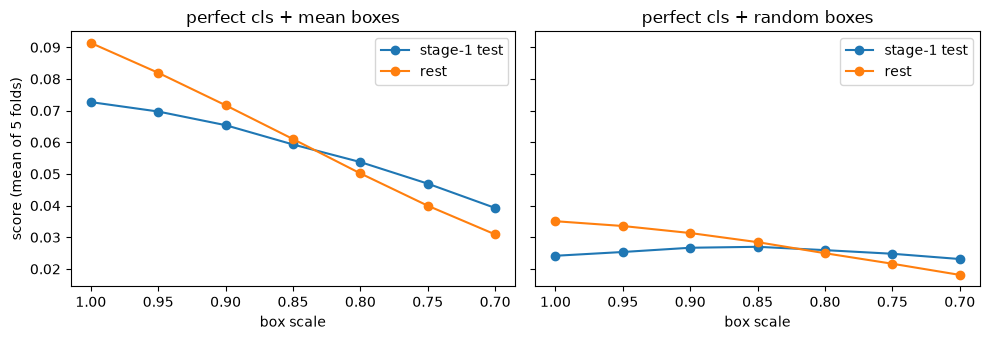

In [11]:
mean_by_scale = shrunk.groupby(["baseline", "scale"])[["stage-1 test", "rest"]].mean()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, name in zip(axes, perfect_names[:2]):
    mean_by_scale.loc[name].plot(ax=ax, marker="o")
    ax.set_title(name)
    ax.set_xlabel("box scale")
    ax.invert_xaxis()
axes[0].set_ylabel("score (mean of 5 folds)")
plt.tight_layout()

### 4.1 Key findings

- **Shrinking hurts the mean boxes on both groups:** from 100% to 70% the score falls from 0.073 to 0.039 on stage-1 and from 0.091 to 0.031 on the rest. The mean box sits at the typical location, not on the opacity, so a smaller box loses overlap faster than it gains from the smaller true boxes.
- **Random boxes show the expected difference, but only as a hint:** on stage-1 the best scale is 0.85-0.90 (0.027 vs 0.024 at 100%), on the rest it is 100% (0.035). The gain of 0.003 is well within the fold std of the stage-1 score (0.011).
- **The full-image box stays at about 0 at every scale** (at most 0.001 on the rest at 70-75%): even at 70% it is 717 px wide and matches only a few very large true boxes.
- **These baselines are too crude to choose a shrink factor.** It has to be tuned on real detector boxes.

**For more reliable results later**

- Tune the shrink factor on out-of-fold detector boxes of all 1,000 stage-1 images together, not per fold: with 59-80 positive stage-1 images per fold, the fold scores of a fixed baseline already differ with a std of 0.011-0.014.